In [37]:
# /opt/local/bin/python3.12 test.py
import sys, string, os, re, glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
plt.rcParams['text.usetex'] = True
sys.path.append("../../python")
sys.path.append("../../python/lib")
from readFile import * 
from readF import *
from modlibUtils import *
sys.path.append("../../build/tools/pyMoDELib")
import pyMoDELib
from utilities import *

In [ ]:
# -----------------------------
# Inputs
# -----------------------------
root_DD = "./LML_MD_Copy_LargerBox_CS1_mu49_Lmin5_Lmax15_QP0.05_RM20"
summary_txt = os.path.join(root_DD, "simulation_summary.txt")

root_MD = "./MD_Data2"
MD_density = os.path.join(root_MD, "dislocationdensity_new.txt")
MD_SS = os.path.join(root_MD, "rate2p5e7.300K.defz.txt")

In [39]:
# ----------------------------
# DDD Data
# ----------------------------
data = np.loadtxt(summary_txt)
evl = data[:, 0].astype(int)
time_s = data[:, 1]
strain = data[:, 2]         # already %
stress = data[:, 3]         # already GPa
rho_total = data[:, 4]      # m^-2
rho_gliss = data[:, 5]
rho_sess  = data[:, 6]
rho_screw = data[:, 9]
rho_edge  = data[:, 10]
rho_mixed = data[:, 11]

In [40]:
# ----------------------------
# MD Data
# ----------------------------
data_density = np.loadtxt(MD_density, skiprows=1)
data_SS = np.loadtxt(MD_SS, skiprows=1)

strain_MD = -1.0*data_SS[:,0]*100
stress_MD = -1.0*data_SS[:,3]  # GPa

# Down Sample Strain for density plots
frame_MD = data_density[:,0]
nFrames = len(frame_MD)
idx = np.linspace(0, len(strain_MD) - 1, nFrames, dtype=int)
strain_MD_sampled = strain_MD[idx]

rho_total_MD = data_density[:,1] # m^-2 
rho_screw_MD = data_density[:,2]
rho_edge_MD  = data_density[:,3]
rho_mixed_MD = data_density[:,4]
rho_junction_MD = data_density[:,5]



In [41]:
def plot_curve_axes(ax, x, y, color, ylabel):
    ax.plot(x, y, color=color, lw=2.0)  # full curve (black, semi-opaque)
    ax.set_xlabel(rf"Strain ($\%$)")
    ax.set_xlim(0.01, 10)
    ax.set_ylabel(ylabel)
    ax.grid(True, ls="--", alpha=0.25)

def plot_two_curve_axes(ax, x1, y1, x2, y2, c1, c2, l1, l2, ylabel):
    ax.plot(x1, y1, color=c1, lw=2.0, label=l1) 
    ax.plot(x2, y2, color=c2, lw=2.0, label=l2) 
    ax.legend(loc='upper right', fontsize=10)
    ax.set_xlabel(rf"Strain ($\%$)")
    ax.set_xlim(0.01, 10)
    ax.set_ylabel(ylabel)
    ax.grid(True, ls="--", alpha=0.25)

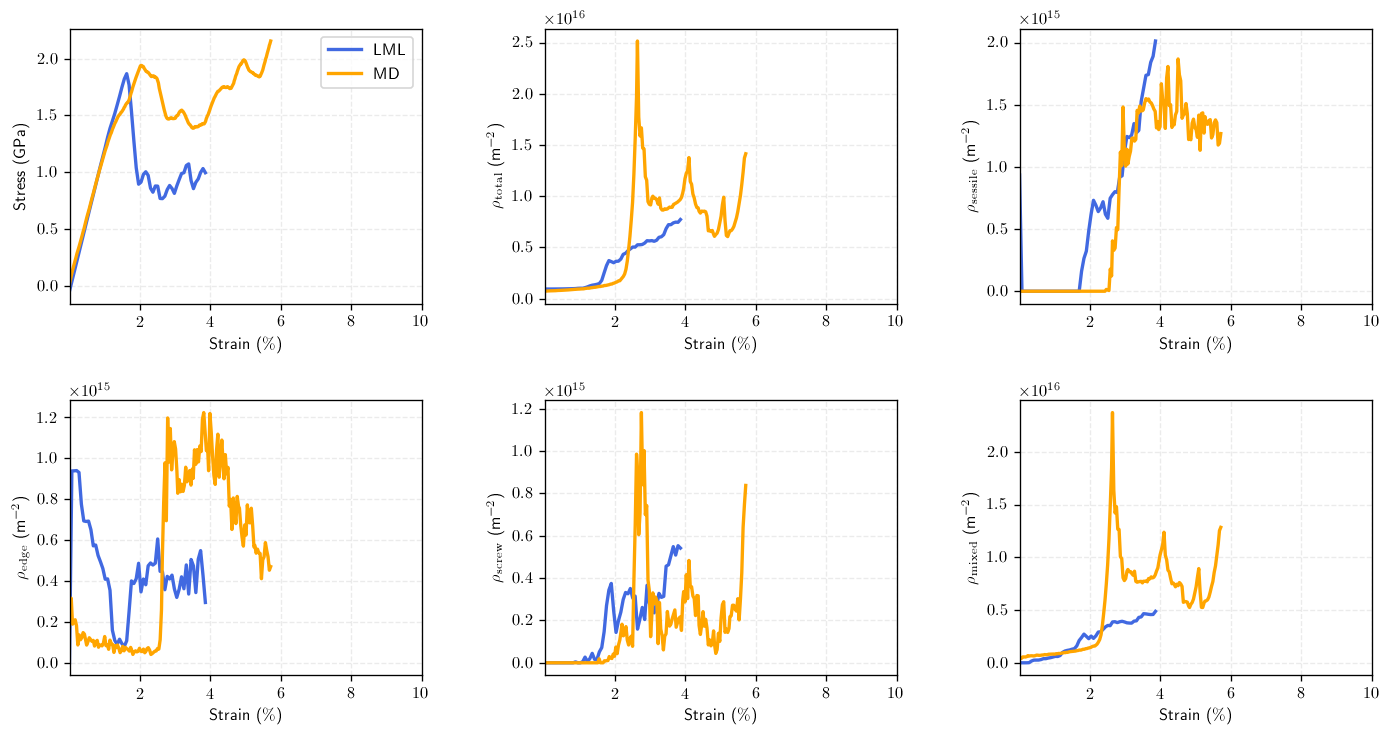

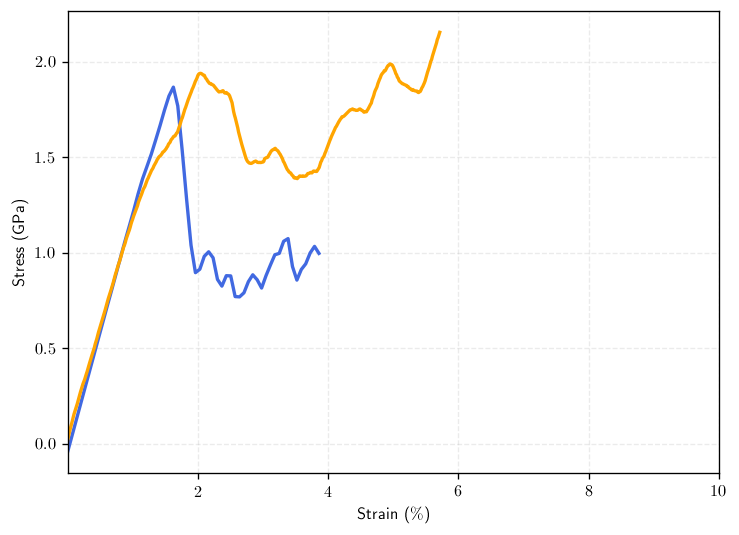

In [42]:
plt.rcParams["figure.dpi"] = 120
fig = plt.figure(figsize=(14, 7))
gs = GridSpec(2, 3, figure=fig, wspace=0.35, hspace=0.35)

ax_ss   = fig.add_subplot(gs[0, 0]) 
ax_tot  = fig.add_subplot(gs[0, 1]) 
ax_ses  = fig.add_subplot(gs[0, 2])
ax_edg  = fig.add_subplot(gs[1, 0]) 
ax_scr  = fig.add_subplot(gs[1, 1])
ax_mix  = fig.add_subplot(gs[1, 2]) 

fig1, ax1 = plt.subplots(figsize=(7, 5))
ax1.plot(strain, stress, color="royalblue", lw=2.0)  # full curve (black, semi-opaque)
ax1.plot(strain_MD, stress_MD, color="orange", lw=2.0)  # full curve (black, semi-opaque)
ax1.set_xlabel(rf"Strain ($\%$)")
ax1.set_xlim(0.01, 10)
ax1.set_ylabel(rf"Stress (GPa)")
ax1.grid(True, ls="--", alpha=0.25)

# Stress-strain (full curve)
plot_two_curve_axes(ax_ss, strain, stress, strain_MD, stress_MD, "royalblue", "orange", "LML", "MD", "Stress (GPa)")

# Density curves (full curve)
plot_curve_axes(ax_tot, strain, rho_total, "royalblue", r"$\rho_{\mathrm{total}}$ (m$^{-2}$)")
plot_curve_axes(ax_tot, strain_MD_sampled, rho_total_MD, "orange", r"$\rho_{\mathrm{total}}$ (m$^{-2}$)")

plot_curve_axes(ax_scr, strain, rho_screw, "royalblue", r"$\rho_{\mathrm{screw}}$ (m$^{-2}$)")
plot_curve_axes(ax_scr, strain_MD_sampled, rho_screw_MD, "orange", r"$\rho_{\mathrm{screw}}$ (m$^{-2}$)")

plot_curve_axes(ax_mix, strain, rho_mixed, "royalblue", r"$\rho_{\mathrm{mixed}}$ (m$^{-2}$)")
plot_curve_axes(ax_mix, strain_MD_sampled, rho_mixed_MD, "orange", r"$\rho_{\mathrm{mixed}}$ (m$^{-2}$)")

plot_curve_axes(ax_edg, strain, rho_edge, "royalblue", r"$\rho_{\mathrm{edge}}$ (m$^{-2}$)")
plot_curve_axes(ax_edg, strain_MD_sampled, rho_edge_MD, "orange", r"$\rho_{\mathrm{edge}}$ (m$^{-2}$)")

plot_curve_axes(ax_ses, strain, rho_sess, "royalblue", r"$\rho_{\mathrm{sessile}}$ (m$^{-2}$)") 
plot_curve_axes(ax_ses, strain_MD_sampled, rho_junction_MD, "orange", r"$\rho_{\mathrm{sessile}}$ (m$^{-2}$)")

fig.savefig(os.path.join(root_DD, "DD_vs_MD_density_stress_strain.pdf"), dpi=1500)
